# User Intent Classification using NLP + BiLSTM
### CLINC150 Dataset — 151 Classes, 23,700 Samples


```

##   1: Install & Import Libraries

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, urllib.request
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##  2: Load CLINC150 Dataset
Load CLINC150 dataset with 23,700 text samples and 151 intent labels.

In [2]:
# Download CLINC150 dataset from GitHub
url = 'https://raw.githubusercontent.com/clinc/oos-eval/master/data/data_full.json'
urllib.request.urlretrieve(url, 'clinc150.json')

with open('clinc150.json') as f:
    data = json.load(f)

# Combine in-scope + out-of-scope splits
train_data = data['train'] + data['oos_train']
val_data   = data['val']   + data['oos_val']
test_data  = data['test']  + data['oos_test']

df_train = pd.DataFrame(train_data, columns=['text', 'intent'])
df_val   = pd.DataFrame(val_data,   columns=['text', 'intent'])
df_test  = pd.DataFrame(test_data,  columns=['text', 'intent'])

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print(f'Total: {len(df_train)+len(df_val)+len(df_test)} samples')
print(f'Intent classes: {df_train["intent"].nunique()}')
df_train.head()

Train: 15100 | Val: 3100 | Test: 5500
Total: 23700 samples
Intent classes: 151


,text,intent
0,what expression would i use to say i love you ...,translate
1,can you tell me how to say 'i do not speak muc...,translate
2,"what is the equivalent of, 'life is good' in f...",translate
3,"tell me how to say, 'it is a beautiful morning...",translate
4,"if i were mongolian, how would i say that i am...",translate


## 3: Preprocessing — Tokenize + Pad + Label Encoding
Convert text to numbers (tokenize) and make all sequences same length (padding).

In [3]:
# --- Label Encoding ---
le = LabelEncoder()
all_intents = pd.concat([df_train, df_val, df_test])['intent']
le.fit(all_intents)

y_train = le.transform(df_train['intent'])
y_val   = le.transform(df_val['intent'])
y_test  = le.transform(df_test['intent'])

# --- Tokenization ---
MAX_WORDS = 20000
MAX_LEN   = 30

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df_train['text'])

X_train = pad_sequences(tokenizer.texts_to_sequences(df_train['text']), maxlen=MAX_LEN, padding='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(df_val['text']),   maxlen=MAX_LEN, padding='post')
X_test  = pad_sequences(tokenizer.texts_to_sequences(df_test['text']),  maxlen=MAX_LEN, padding='post')

print(f'Vocab size: {len(tokenizer.word_index)}')
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'Classes: {len(le.classes_)}')

# Save artifacts
with open('tokenizer.pkl', 'wb') as f: pickle.dump(tokenizer, f)
with open('label_encoder.pkl', 'wb') as f: pickle.dump(le, f)

Vocab size: 5351
X_train: (15100, 30) | X_val: (3100, 30) | X_test: (5500, 30)
Classes: 151


##  4: Build BiLSTM Model
Build BiLSTM model: reads text forward+backward to understand context better.

In [4]:
VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
EMBED_DIM = 100
NUM_CLASSES = len(le.classes_)

model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-3),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5: Train the Model
Train model on data, it learns which words map to which intents over 20 rounds.

Epoch 1/20
235/236 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0121 - loss: 4.9321
Epoch 1: val_loss improved from None to 3.72048, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.0240 - loss: 4.6531 - val_accuracy: 0.1045 - val_loss: 3.7205
Epoch 2/20
233/236 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1354 - loss: 3.3982
Epoch 2: val_loss improved from 3.72048 to 2.06889, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2009 - loss: 3.0051 - val_accuracy: 0.4684 - val_loss: 2.0689
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4418 - loss: 1.8831
Epoch 3: val_loss improved from 2.06889 to 1.28401, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4884 - loss: 1.7260 - val_accuracy: 0.

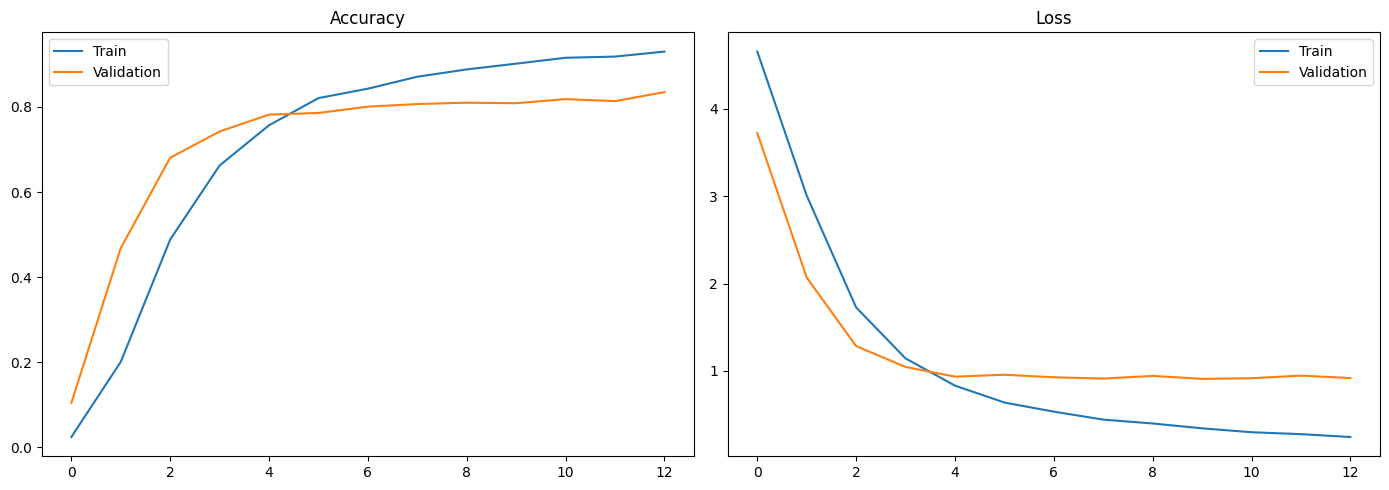


Best Val Accuracy: 0.8348


In [5]:
callbacks = [EarlyStopping(patience=3, restore_best_weights=True, verbose=1),ModelCheckpoint('best_model.keras', save_best_only=True, verbose=1)]

history = model.fit(X_train, y_train,validation_data=(X_val, y_val),epochs=20,batch_size=64,callbacks=callbacks)

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy'); ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss'); ax2.legend()

plt.tight_layout()
plt.show()

print(f'\nBest Val Accuracy: {max(history.history["val_accuracy"]):.4f}')

## 6: Evaluate on Test Set
 Test on unseen data to measure real accuracy using classification report.

In [7]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}')

y_pred = np.argmax(model.predict(X_test), axis=1)
print('\nClassification Report (top 10 classes):')
print(classification_report(y_test, y_pred, target_names=le.classes_, labels=np.arange(10)))

Test Accuracy: 0.7009 | Test Loss: 1.5809
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report (top 10 classes):
                           precision    recall  f1-score   support

      accept_reservations       0.73      0.73      0.73        30
          account_blocked       0.59      0.87      0.70        30
                    alarm       0.85      0.97      0.91        30
       application_status       0.94      1.00      0.97        30
                      apr       0.85      0.97      0.91        30
            are_you_a_bot       0.71      1.00      0.83        30
                  balance       0.50      0.97      0.66        30
             bill_balance       0.53      0.63      0.58        30
                 bill_due       0.74      0.77      0.75        30
              book_flight       0.93      0.87      0.90        30

                micro avg       0.71      0.88      0.79       300
                macro avg       0.74      0.88      0.79       300
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 10, does not match size of target_names, 151
  warnings.warn(


##  7: Live Inference
Give new text input, model predicts top 3 most likely intents with confidence %.

In [8]:
text="what is weather like today"
seq = pad_sequences(tokenizer.texts_to_sequences([text]), maxlen=MAX_LEN, padding='post')
probs=model.predict(seq,verbose=0)[0]
top_idx=probs.argsort()[-3:][::-1]

print("input: ",text)
print("1st:", le.classes_[top_idx[0]], round(probs[top_idx[0]]*100, 1), "%")
print("2nd:", le.classes_[top_idx[1]], round(probs[top_idx[1]]*100, 1), "%")
print("3rd:", le.classes_[top_idx[2]], round(probs[top_idx[2]]*100, 1), "%")



input:  what is weather like today
1st: weather 99.9 %
2nd: taxes 0.1 %
3rd: direct_deposit 0.0 %


##  8: Export Model

In [10]:


# Save model
model.save('intent_model.keras')

# Save tokenizer
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Download all files to your PC
from google.colab import files
files.download('intent_model.keras')
files.download('tokenizer.pkl')
files.download('label_encoder.pkl')

print("✅ Model exported successfully!")
print("Files saved: intent_model.h5, tokenizer.pkl, label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model exported successfully!
Files saved: intent_model.h5, tokenizer.pkl, label_encoder.pkl


In [11]:
import os
print(os.listdir())

['.config', 'clinc150.json', 'best_model.keras', 'tokenizer.pkl', 'intent_model.keras', 'label_encoder.pkl', 'sample_data']
